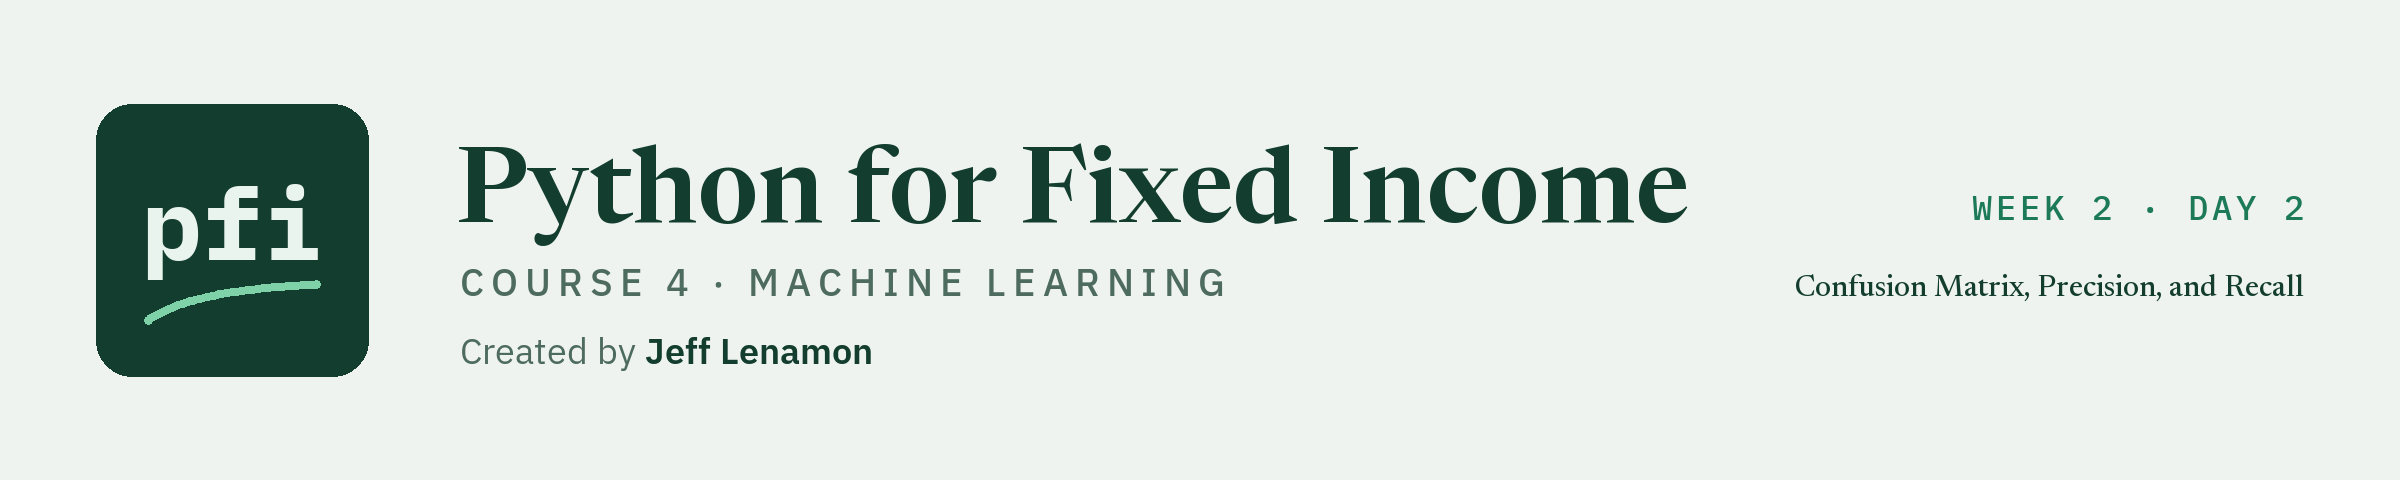

# Confusion Matrix, Precision, and Recall

Week 2, Day 2. A probability becomes a flag, and a flag can be right or wrong in two ways. Today: the confusion matrix read cell by cell, why accuracy hides the rare class, and precision, recall, and F1 for the defaults, on validation rows.

**Data:** `credit_card_default.csv`, 30,000 card accounts in Taiwan in 2005: **real**, UCI Machine Learning Repository dataset 350, CC BY 4.0. Citation: Yeh, I. (2009). Default of Credit Card Clients [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55S3H.

> This course is educational content created in a personal capacity. Nothing here is investment advice or a recommendation to buy or sell any security. All portfolio data is synthetic.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lenamonj/python-fixed-income/blob/main/course4_machine_learning/week2/day2/07_confusion_matrix_precision_and_recall.ipynb)

Yesterday, day 6, a logistic regression turned 19 columns of each card account into a **model probability of default in this file**. A probability is not yet an answer to the question a desk asks of a list of accounts: which ones does the model flag? Today a threshold turns each probability into a flag, 1 or 0, and the flags are counted against what happened.

There are two ways to be right and two ways to be wrong, and the four counts that hold them are the **confusion matrix**. Every classification metric in the course is built from those four counts. The first lesson of the day is that the most familiar one, accuracy, can look good while the model catches no defaults at all.

**The data is real.** `credit_card_default.csv` holds 30,000 card accounts from the UCI Machine Learning Repository, with the citation above. The accounts are in Taiwan in 2005, and consumer credit there differs from US credit. Everything a model fitted to this file shows describes this file. A flag in this notebook is **flagged at threshold t** and nothing more: never a credit decision, never an approval or a decline of a real person.

`SEX`, `EDUCATION`, `MARRIAGE`, and `AGE` describe people, and they are **never model features** in this course. The course describes a file and builds no lending rule; a model that read these columns would sort people by them; and leaving them out does not make a model neutral, because other columns can carry the same information. Every week 2 model reads the other 19 columns.

**The week 2 split.** Every week 2 notebook splits the accounts the same way: 60 percent training rows to fit, 20 percent validation rows to choose and to report this week's numbers, and 20 percent test rows, put away until day 10 and opened once there. Today uses the training and validation rows only.

Today you will:

1. Rebuild the split and day 6's model, and read its probabilities on the validation rows.
2. Score the all-zero model, which flags nobody, and see its accuracy.
3. Lay out the confusion matrix with labels and read it cell by cell, with `confusion_counts`.
4. Compute precision, recall, and F1 for the default class, with `classification_metrics`.
5. See what threshold 0.5 catches, and what changes at 0.25, as arithmetic on counts.
6. Read scikit-learn's `classification_report` line by line.

Q. Set up today's work folder: the thread settings, the seed, today's four data files, and the module as day 6 left it.

In [1]:
# today's setup: the thread settings, the modules, the seed, the course data, and a fresh work folder
import os

# one thread for the maths libraries, so every run of the notebook gives the same last digits.
# These two lines must run before numpy, pandas, or scikit-learn is imported: if you ran another cell first,
# restart the kernel and run this cell first (in Colab: Runtime, Restart session).
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"

import importlib
import importlib.metadata
import platform
import shutil
import subprocess
import sys
import tempfile
import urllib.request
from pathlib import Path

# four packages a Colab runtime or a new environment may lack: stop with the line that installs the missing one
for module_name, install_name in [("sklearn", "scikit-learn"), ("statsmodels", "statsmodels"), ("scipy", "scipy"), ("pytest", "pytest")]:
    try:
        importlib.import_module(module_name)
    except ImportError:
        raise RuntimeError(f"{install_name} is not installed. Run  !pip install {install_name}  in a new cell, "
                           "then run this cell again.") from None

import numpy as np
import pandas as pd

# the versions the saved outputs of this notebook came from (course4_machine_learning/requirements.txt)
PINNED = {"numpy": "2.5.3", "pandas": "3.0.6", "scikit-learn": "1.9.1", "statsmodels": "0.15.0", "scipy": "1.18.1", "matplotlib": "3.11.2", "pytest": "9.1.1"}
installed = {name: importlib.metadata.version(name) for name in PINNED}
print(f"Python {platform.python_version()}; " + ", ".join(f"{name} {version}" for name, version in installed.items()))
different = [name for name in PINNED if installed[name] != PINNED[name]]
if different:
    print(f"Not the course's pinned version: {', '.join(different)}. Printed numbers may differ in the last digits from the saved notebook.")

# the seed: one number for every random choice the course makes, so every run makes the same choices
SEED = 42

# remember the notebook's own folder, so that running this cell again starts from the same place
if "notebook_folder" not in globals():
    notebook_folder = Path.cwd()

# 1. find the course data before moving: the repo's data folder on your machine, GitHub in Colab
RAW_DATA = "https://raw.githubusercontent.com/lenamonj/python-fixed-income/main/data/"
local_data = (notebook_folder / ".." / ".." / ".." / "data").resolve()
on_github = not (local_data / "benchmark.csv").exists()

# 2. a fresh work folder for today, in the system temp folder, outside the course repo
work = Path(tempfile.mkdtemp(prefix="pfi_course4_07_"))
os.chdir(work)

# 3. copy today's data files into the work folder
DATA_FILES = ["benchmark.csv", "ratings.csv", "course4_excel_reference.csv", "credit_card_default.csv"]
for name in DATA_FILES:
    if on_github:
        urllib.request.urlretrieve(RAW_DATA + name, work / name)
    else:
        shutil.copy(local_data / name, work / name)

# print the folder's name only: its full path would show your user name
print(f"Work folder: {work.name}, in your temp folder")
print(f"Data files from {'GitHub' if on_github else 'the data folder of the course repo'}: {', '.join(DATA_FILES)}")
print(f"SEED = {SEED}")

Python 3.13.8; numpy 2.5.3, pandas 3.0.6, scikit-learn 1.9.1, statsmodels 0.15.0, scipy 1.18.1, matplotlib 3.11.2, pytest 9.1.1
Work folder: pfi_course4_07_cyuxmjei, in your temp folder
Data files from the data folder of the course repo: benchmark.csv, ratings.csv, course4_excel_reference.csv, credit_card_default.csv
SEED = 42


Q. Write `mlkit.py` and `test_mlkit.py` as they stand at the start of today: the reference version at the end of the last notebook.

In [2]:
%%writefile mlkit.py
"""mlkit: the small pieces of machine learning that scikit-learn leaves to the analyst, written down and tested.

Written day by day in Python for Fixed Income, Course 4: Machine Learning.

Conventions, the same in every function:
- The seed is 42 wherever a function takes one, so every run gives the same numbers.
- Spreads are in basis points (bp). A model of log_oas is fitted in natural logs of bp; its errors are reported
  in bp after exp, and exp of a fitted log is a median-type value, not a mean.
- The positive class is 1 (default, bankrupt). Precision, recall, and F1 are for class 1 only.
- A row is flagged when its model probability is at least the threshold (probability >= threshold).
- Rows that fit a model, rows that choose a setting, and rows that report a result are kept apart; the split
  functions here prove it with a check that stops.
- Inputs of the wrong shape, or empty inputs, raise ValueError with a message that says what was wrong.
"""
import numpy as np  # arrays and arithmetic
import pandas as pd  # tables with labels
from numpy.typing import ArrayLike  # a list, an array, or a pandas Series


def assert_disjoint(train_index: ArrayLike, test_index: ArrayLike) -> None:
    """Stop if any row label is in both the training rows and the test rows.

    Inputs: the labels (or positions) of the rows in each part, for example X_train.index and X_test.index.
    Output: None when the parts share no label.
    Convention: a row in both parts is a test row the model has already seen, which flatters every metric.
    Raises AssertionError naming how many labels are in both parts, and ValueError if either part is empty.
    """
    # the labels of each part as sets
    train = set(np.asarray(train_index).tolist())
    test = set(np.asarray(test_index).tolist())
    if not train or not test:
        raise ValueError("train_index and test_index must both hold at least one label")
    # the labels found in both parts
    shared = train & test
    if shared:
        raise AssertionError(f"{len(shared)} row labels are in both the training and the test rows")


def _as_1d_array(values: ArrayLike, name: str) -> np.ndarray:
    """Return `values` as a 1-D float array, or raise ValueError naming the input."""
    array = np.asarray(values, dtype=float)
    if array.ndim != 1:
        raise ValueError(f"{name} must be one-dimensional, not {array.ndim}-dimensional")
    if array.size == 0:
        raise ValueError(f"{name} is empty")
    return array


def regression_metrics(y_true: ArrayLike, y_fitted: ArrayLike) -> dict[str, float]:
    """R-squared, mean absolute error, and root mean squared error of fitted values.

    Inputs: y_true and y_fitted, the same length, in the target's unit (for example oas in bp).
    Output: {"r2", "mae", "rmse"}. r2 is unitless, 1 - SS_res / SS_tot on the rows given (on test rows it can
    be negative); mae and rmse are in the target's unit. For a log_oas model, pass exp of both to get bp.
    Convention: equal to scikit-learn's r2_score, mean_absolute_error, and root_mean_squared_error.
    Excel: =RSQ(...) only for a straight line on one feature; =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)).
    Raises ValueError if the inputs are empty, not one-dimensional, or of different lengths.
    """
    # check both inputs and that they line up row for row
    actual = _as_1d_array(y_true, "y_true")
    fitted = _as_1d_array(y_fitted, "y_fitted")
    if actual.size != fitted.size:
        raise ValueError(f"y_true has {actual.size} values and y_fitted has {fitted.size}")
    # each error in the target's unit
    errors = actual - fitted
    # R-squared: the share of the spread around the mean that the fitted values account for
    ss_res = float(np.sum(errors ** 2))
    ss_tot = float(np.sum((actual - actual.mean()) ** 2))
    r2 = 1 - ss_res / ss_tot
    # the average size of an error, and the square root of the average squared error
    mae = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))
    return {"r2": r2, "mae": mae, "rmse": rmse}


def adjusted_r2(r2: float, n_rows: int, n_features: int) -> float:
    """Adjusted R-squared: R-squared with a charge for each feature.

    Inputs: r2 on the training rows (unitless), n_rows the number of training rows, n_features the number of
    features not counting the intercept.
    Output: 1 - (1 - r2) x (n_rows - 1) / (n_rows - n_features - 1), unitless. An in-sample measure, so it is
    computed on training rows only.
    Excel: =1-(1-R2)*(n-1)/(n-k-1)
    Raises ValueError if n_features is negative or n_rows is not above n_features + 1.
    """
    # the formula needs at least one degree of freedom left after the features and the intercept
    if n_features < 0:
        raise ValueError(f"n_features must be 0 or more, not {n_features}")
    if n_rows <= n_features + 1:
        raise ValueError(f"n_rows ({n_rows}) must be greater than n_features + 1 ({n_features + 1})")
    # scale the unexplained share by the ratio of degrees of freedom
    return 1 - (1 - r2) * (n_rows - 1) / (n_rows - n_features - 1)


def rating_dummies(ratings: pd.Series, levels: list[str], reference: str) -> pd.DataFrame:
    """One indicator column per rating level except the reference level, which the intercept stands for.

    Inputs: ratings, one text rating per bond (for example "BBB+"); levels, every allowed level in the order the
    columns should follow (the rating column of ratings.csv, known in advance, not learned from the data);
    reference, the level left out.
    Output: a DataFrame with the same index, one float column (0.0 or 1.0) per level except reference, named
    rating_<level>, in the order of levels. A coefficient on rating_BB is then the difference from a bond rated
    `reference`, other features fixed.
    Convention: floats, not booleans, so every library and an Excel formula read the same 0.0 and 1.0. The
    reference is named by the caller, never chosen by alphabetical order.
    Raises ValueError if ratings is empty, reference is not in levels, or a rating is not in levels.
    """
    # check the inputs before building anything
    if len(ratings) == 0:
        raise ValueError("ratings is empty")
    if reference not in levels:
        raise ValueError(f"reference {reference!r} is not one of the levels")
    unknown = sorted(set(ratings) - set(levels))
    if unknown:
        raise ValueError(f"ratings not in levels: {unknown}")
    # one column per level, 1.0 where the bond has that rating
    columns = {f"rating_{level}": (ratings == level).astype(float) for level in levels if level != reference}
    return pd.DataFrame(columns, index=ratings.index)


def vif_table(X: pd.DataFrame) -> pd.Series:
    """Variance inflation factor of each feature: how much its coefficient's variance grows from the overlap with
    the other features.

    Input: X, the features as numeric columns (no constant column; one is added inside).
    Output: a Series named vif, one value per column, sorted from highest to lowest. VIF_j = 1 / (1 - R2_j),
    where R2_j is the R-squared of column j regressed on a constant and every other column. 1 means no overlap;
    above 5 is called high and above 10 very high, as conventions. A column that is an exact copy (or exact
    combination) of others has R2_j = 1 and VIF infinity.
    Convention: equal to statsmodels' variance_inflation_factor on X with a constant added.
    Excel: =1/(1-INDEX(LINEST(xj, other columns, TRUE, TRUE), 3, 1))
    Raises ValueError if X has fewer than two columns or fewer rows than columns plus two.
    """
    # check there is something to regress on, and enough rows to do it
    if X.shape[1] < 2:
        raise ValueError(f"X needs at least two columns, not {X.shape[1]}")
    if X.shape[0] < X.shape[1] + 2:
        raise ValueError(f"X has {X.shape[0]} rows, too few for {X.shape[1]} columns")
    values = X.to_numpy(dtype=float)
    result = {}
    for j, name in enumerate(X.columns):
        # column j is the target; a constant and the other columns are the features
        target = values[:, j]
        others = np.column_stack([np.ones(len(values)), np.delete(values, j, axis=1)])
        # least squares fit and its R-squared
        coefficients, *_ = np.linalg.lstsq(others, target, rcond=None)
        ss_res = float(np.sum((target - others @ coefficients) ** 2))
        ss_tot = float(np.sum((target - target.mean()) ** 2))
        r2 = 1 - ss_res / ss_tot
        # an exact combination of the others leaves no residual (R-squared 1 to the last digit): the VIF is infinite
        result[name] = np.inf if r2 >= 1 else 1 / (1 - r2)
    return pd.Series(result, name="vif").sort_values(ascending=False)


from scipy import stats  # Jarque-Bera and Shapiro-Wilk
from statsmodels.stats.diagnostic import het_breuschpagan  # Breusch-Pagan
from statsmodels.tools import add_constant  # the intercept column


def residual_tests(residuals: pd.Series, exog: pd.DataFrame) -> dict[str, float]:
    """p-values of three checks on a regression's residuals: constant variance and normality (two tests).

    Inputs: residuals, actual minus fitted on the training rows, in the target's unit; exog, the features the
    model was fitted on, without a constant (one is added inside), with the same rows.
    Output: {"breusch_pagan", "jarque_bera", "shapiro_wilk"}, each a p-value between 0 and 1. A small p-value
    (below 0.05, the course's convention) means the data would be surprising if the assumption held:
    - breusch_pagan: statsmodels het_breuschpagan with its default (Koenker's form, n x R-squared of the squared
      residuals regressed on a constant and exog); the assumption is constant variance;
    - jarque_bera: scipy.stats.jarque_bera (skew and kurtosis); the assumption is normal residuals;
    - shapiro_wilk: scipy.stats.shapiro; the assumption is normal residuals.
    Excel has no function for these; Breusch-Pagan can be built from LINEST and CHISQ.DIST.RT.
    Raises ValueError if the inputs are empty or have different numbers of rows.
    """
    # check the two inputs line up
    if len(residuals) == 0 or len(exog) == 0:
        raise ValueError("residuals and exog must not be empty")
    if len(residuals) != len(exog):
        raise ValueError(f"residuals has {len(residuals)} rows and exog has {len(exog)}")
    values = np.asarray(residuals, dtype=float)
    # Breusch-Pagan: returns the LM statistic, its p-value, then an F form; the LM p-value is kept
    _, bp_pvalue, _, _ = het_breuschpagan(values, add_constant(np.asarray(exog, dtype=float), has_constant="add"))
    # the two normality tests
    jb_pvalue = stats.jarque_bera(values).pvalue
    sw_pvalue = stats.shapiro(values).pvalue
    return {"breusch_pagan": float(bp_pvalue), "jarque_bera": float(jb_pvalue), "shapiro_wilk": float(sw_pvalue)}


from sklearn.pipeline import Pipeline  # the type of a chain of steps


def named_coefficients(pipeline: Pipeline) -> pd.Series:
    """The fitted coefficients of a pipeline's last step, labelled with the feature names that step saw.

    Input: a fitted scikit-learn Pipeline whose last step has coef_ (LinearRegression, Ridge, Lasso,
    LogisticRegression) and whose step before it has get_feature_names_out (a ColumnTransformer, a scaler).
    Output: a Series of coefficients indexed by feature name, in the order the model used them. Units: per unit
    of each feature as the model saw it, so per standard deviation after StandardScaler; the intercept is not
    included. For a binary LogisticRegression the one row of coef_ is used (log-odds of class 1).
    Raises ValueError if the last step has no coef_ (a tree, for example) or the pipeline has one step only.
    """
    # the model is the last step; the names come from everything before it
    if len(pipeline.steps) < 2:
        raise ValueError("the pipeline needs a preprocessing step before the model")
    model = pipeline.steps[-1][1]
    if not hasattr(model, "coef_"):
        raise ValueError(f"the last step, {type(model).__name__}, has no coef_")
    names = pipeline[:-1].get_feature_names_out()
    # a binary classifier keeps its coefficients in one row; flatten it
    coefficients = np.ravel(model.coef_)
    if coefficients.size != len(names):
        raise ValueError(f"{coefficients.size} coefficients but {len(names)} feature names")
    return pd.Series(coefficients, index=names, name="coefficient")


def odds_ratios(coefficients: pd.Series) -> pd.Series:
    """Odds ratios from logistic regression coefficients: exp of each coefficient, the intercept left out.

    Input: coefficients in log-odds, indexed by feature name, as statsmodels' Logit params (the intercept is
    named "const") or a Series with an entry named "intercept".
    Output: a Series of exp(coefficient) per feature: the factor by which the odds of class 1 multiply for one
    more unit of that feature, other features fixed. The unit is the feature's own (per 10,000 NT dollars if the
    feature was divided by 10,000; per standard deviation if it was scaled).
    Excel: =EXP(coef)
    Raises ValueError if no coefficient is left once the intercept is removed.
    """
    # leave out the intercept: exp of it is the odds when every feature is 0, not a ratio
    slopes = coefficients.drop(labels=["const", "intercept"], errors="ignore")
    if slopes.empty:
        raise ValueError("no coefficients left after removing the intercept")
    return np.exp(slopes).rename("odds_ratio")


def logistic_probability(z: float | ArrayLike) -> float | np.ndarray:
    """The logistic curve: turns log-odds z into a probability between 0 and 1.

    Input: z, a number or an array of numbers in log-odds (intercept plus coefficients times features).
    Output: 1 / (1 + exp(-z)), a float for a number, an array for an array. z = 0 gives 0.5.
    Excel: =1/(1+EXP(-z))
    """
    # numpy's exp works on a number and on an array alike
    probability = 1 / (1 + np.exp(-np.asarray(z, dtype=float)))
    return float(probability) if probability.ndim == 0 else probability

Writing mlkit.py


In [3]:
%%writefile test_mlkit.py
"""Tests for mlkit.py.

Expected values come from Excel (course4_excel_reference.csv in this folder), from scikit-learn or statsmodels on
the same inputs, or from small examples worked by hand. No test touches the network.
Run from this folder with:  python -m pytest
"""
from pathlib import Path

import numpy as np
import pandas as pd
import pytest
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

import mlkit

HERE = Path(__file__).resolve().parent
SEED = 42


def read_bench() -> pd.DataFrame:
    """The 821 synthetic benchmark bonds joined to their rating score, with log_oas (natural log of bp)."""
    bench = pd.read_csv(HERE / "benchmark.csv")
    ratings = pd.read_csv(HERE / "ratings.csv")
    bench = bench.merge(ratings[["rating", "score"]], on="rating", how="left", validate="many_to_one")
    bench["log_oas"] = np.log(bench["oas"])
    return bench


def excel(case_id: str) -> float:
    """One value computed by Excel, looked up by its case_id (model:quantity)."""
    reference = pd.read_csv(HERE / "course4_excel_reference.csv", float_precision="round_trip")
    return float(reference.set_index("case_id").loc[case_id, "excel_value"])


def test_assert_disjoint_passes():
    mlkit.assert_disjoint([0, 1, 2], [3, 4])


def test_assert_disjoint_raises_with_count():
    with pytest.raises(AssertionError, match="2 row labels"):
        mlkit.assert_disjoint([0, 1, 2, 3], [2, 3, 4])


def test_regression_metrics_hand_values():
    # errors 10, -10, 30 bp around a mean of 200 bp
    metrics = mlkit.regression_metrics([100.0, 200.0, 300.0], [110.0, 190.0, 330.0])
    assert metrics["mae"] == pytest.approx(50 / 3, abs=1e-12)
    assert metrics["rmse"] == pytest.approx(np.sqrt(1100 / 3), abs=1e-12)
    # SS_res 1,100 over SS_tot 20,000
    assert metrics["r2"] == pytest.approx(1 - 1100 / 20000, abs=1e-12)


def test_regression_metrics_match_sklearn():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(r2_score(bench["oas"], fitted), abs=1e-12)
    assert metrics["mae"] == pytest.approx(mean_absolute_error(bench["oas"], fitted), abs=1e-12)
    assert metrics["rmse"] == pytest.approx(root_mean_squared_error(bench["oas"], fitted), abs=1e-12)
    with pytest.raises(ValueError):
        mlkit.regression_metrics([1.0, 2.0], [1.0])


def test_slope_matches_excel_reference():
    bench = read_bench()
    slope, intercept = np.polyfit(bench["score"], bench["oas"], 1)
    # Excel: =SLOPE(oas, score), =INTERCEPT(oas, score), =RSQ(oas, score) over the 821 bonds
    assert slope == pytest.approx(excel("d01_oas_on_score:slope"), abs=1e-9)
    assert intercept == pytest.approx(excel("d01_oas_on_score:intercept"), abs=1e-9)
    fitted = intercept + slope * bench["score"]
    metrics = mlkit.regression_metrics(bench["oas"], fitted)
    assert metrics["r2"] == pytest.approx(excel("d01_oas_on_score:rsq"), abs=1e-9)
    # Excel: =AVERAGE(ABS(a-b)) and =SQRT(SUMXMY2(a,b)/COUNT(a)), in bp
    assert metrics["mae"] == pytest.approx(excel("d01_oas_on_score:mae_bp"), abs=1e-9)
    assert metrics["rmse"] == pytest.approx(excel("d01_oas_on_score:rmse_bp"), abs=1e-9)


import statsmodels.api as sm


def rating_levels() -> list[str]:
    """Every rating level, AAA to CCC, in the order of ratings.csv."""
    return pd.read_csv(HERE / "ratings.csv")["rating"].tolist()


def sector_dummies(sectors: pd.Series, reference: str = "Consumer") -> pd.DataFrame:
    """One float column per sector except the reference, named sector_<name>, in alphabetical order."""
    return pd.DataFrame({f"sector_{s}": (sectors == s).astype(float) for s in sorted(sectors.unique())
                         if s != reference}, index=sectors.index)


def test_adjusted_r2_hand_value():
    # 1 - (1 - 0.8) x 99 / 96
    assert mlkit.adjusted_r2(0.8, 100, 3) == pytest.approx(1 - 0.2 * 99 / 96, abs=1e-12)


def test_adjusted_r2_rejects_too_few_rows():
    with pytest.raises(ValueError):
        mlkit.adjusted_r2(0.8, 4, 3)


def test_rating_dummies_reference_absent():
    ratings = pd.Series(["AAA", "A", "BBB", "A"])
    dummies = mlkit.rating_dummies(ratings, ["AAA", "A", "BBB"], reference="A")
    assert list(dummies.columns) == ["rating_AAA", "rating_BBB"]
    # an A-rated bond has every indicator at 0.0: the intercept stands for it
    assert dummies.loc[1].tolist() == [0.0, 0.0]
    assert dummies.dtypes.eq(float).all()


def test_rating_dummies_unknown_level_raises():
    with pytest.raises(ValueError, match="BB"):
        mlkit.rating_dummies(pd.Series(["AAA", "BB"]), ["AAA", "A"], reference="A")
    with pytest.raises(ValueError):
        mlkit.rating_dummies(pd.Series(["AAA"]), ["AAA", "A"], reference="CCC")


def test_linest_multi_matches_excel_reference():
    bench = read_bench()
    X = pd.concat([mlkit.rating_dummies(bench["rating"], rating_levels(), reference="A"),
                   bench[["duration"]], sector_dummies(bench["sector"])], axis=1)
    fit = sm.OLS(bench["oas"], sm.add_constant(X)).fit()
    model = "d02_oas_on_rating_duration_sector"
    # Excel's LINEST reverses the columns; the reference file names each value in statsmodels' order
    for name in ["const"] + list(X.columns):
        assert fit.params[name] == pytest.approx(excel(f"{model}:coef_{name}"), abs=1e-9), name
        assert fit.bse[name] == pytest.approx(excel(f"{model}:se_{name}"), abs=1e-9), name
    assert fit.rsquared == pytest.approx(excel(f"{model}:r2"), abs=1e-9)
    assert fit.df_resid == excel(f"{model}:df_resid")
    assert fit.fvalue == pytest.approx(excel(f"{model}:f"), rel=1e-9)
    adjusted = mlkit.adjusted_r2(fit.rsquared, len(X), X.shape[1])
    assert adjusted == pytest.approx(excel(f"{model}:adj_r2"), abs=1e-9)
    assert adjusted == pytest.approx(fit.rsquared_adj, abs=1e-12)


from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor


def m3_features(bench: pd.DataFrame) -> pd.DataFrame:
    """Rating score, duration, and the nine sector dummies (reference Consumer): the day 3 inference model."""
    return pd.concat([bench[["score", "duration"]], sector_dummies(bench["sector"])], axis=1)


def test_vif_matches_statsmodels():
    X = m3_features(read_bench())
    vifs = mlkit.vif_table(X)
    with_constant = sm.add_constant(X).to_numpy()
    for j, name in enumerate(X.columns, start=1):
        assert vifs[name] == pytest.approx(variance_inflation_factor(with_constant, j), abs=1e-9), name
    # sorted from the highest VIF down
    assert vifs.is_monotonic_decreasing


def test_vif_matches_excel_reference():
    vifs = mlkit.vif_table(m3_features(read_bench()))
    for name, value in vifs.items():
        # Excel: =1/(1-INDEX(LINEST(xj, the other columns, TRUE, TRUE), 3, 1))
        assert value == pytest.approx(excel(f"d03_vif:vif_{name}"), abs=1e-9), name


def test_vif_perfect_collinearity_is_huge():
    bench = read_bench()
    # spread_duration equals duration on every bond of the file
    vifs = mlkit.vif_table(bench[["score", "duration", "spread_duration"]])
    assert vifs["duration"] > 1e10
    assert vifs["spread_duration"] > 1e10
    assert vifs["score"] < 5


def test_ols_matches_sklearn():
    bench = read_bench()
    X = m3_features(bench)
    fit = sm.OLS(bench["log_oas"], sm.add_constant(X)).fit()
    linear = LinearRegression().fit(X, bench["log_oas"])
    assert linear.intercept_ == pytest.approx(fit.params["const"], abs=1e-9)
    for name, value in zip(X.columns, linear.coef_):
        assert value == pytest.approx(fit.params[name], abs=1e-9), name
    # and both against Excel's LINEST, with its standard errors and T.DIST.2T p-values
    model = "d03_log_oas_on_score_duration_sector"
    for name in fit.params.index:
        assert fit.params[name] == pytest.approx(excel(f"{model}:coef_{name}"), abs=1e-9), name
        assert fit.bse[name] == pytest.approx(excel(f"{model}:se_{name}"), abs=1e-9), name
        assert fit.pvalues[name] == pytest.approx(excel(f"{model}:p_{name}"), abs=1e-9), name


from scipy import stats
from statsmodels.stats.diagnostic import het_breuschpagan


def test_residual_tests_match_statsmodels_and_scipy():
    bench = read_bench()
    X = pd.concat([mlkit.rating_dummies(bench["rating"], rating_levels(), reference="A"),
                   bench[["duration"]], sector_dummies(bench["sector"])], axis=1)
    fit = sm.OLS(bench["log_oas"], sm.add_constant(X)).fit()
    result = mlkit.residual_tests(fit.resid, X)
    assert result["breusch_pagan"] == pytest.approx(het_breuschpagan(fit.resid, sm.add_constant(X))[1], abs=1e-12)
    assert result["jarque_bera"] == pytest.approx(stats.jarque_bera(fit.resid).pvalue, abs=1e-12)
    assert result["shapiro_wilk"] == pytest.approx(stats.shapiro(fit.resid).pvalue, abs=1e-12)
    # Excel: LM = n x INDEX(LINEST(squared residuals, X, TRUE, TRUE), 3, 1), then CHISQ.DIST.RT(LM, k)
    model = "d04_breusch_pagan_log_oas_model"
    assert het_breuschpagan(fit.resid, sm.add_constant(X))[0] == pytest.approx(excel(f"{model}:lm"), rel=1e-9)
    assert result["breusch_pagan"] == pytest.approx(excel(f"{model}:lm_pvalue"), abs=1e-9)


def test_residual_tests_normal_sample():
    rng = np.random.default_rng(SEED)
    exog = pd.DataFrame({"x": rng.uniform(0, 10, 500)})
    residuals = pd.Series(rng.normal(0, 1, 500))
    # residuals drawn normal with constant variance: no check rejects at 0.05
    result = mlkit.residual_tests(residuals, exog)
    assert min(result.values()) > 0.05


def test_residual_tests_fan_rejected():
    rng = np.random.default_rng(SEED)
    x = np.arange(1.0, 201.0)
    # the spread of the residuals grows with x: a fan
    residuals = pd.Series(x * rng.normal(0, 1, 200))
    result = mlkit.residual_tests(residuals, pd.DataFrame({"x": x}))
    assert result["breusch_pagan"] < 0.001
    with pytest.raises(ValueError):
        mlkit.residual_tests(residuals, pd.DataFrame({"x": x[:10]}))


from sklearn.compose import ColumnTransformer
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor


def spread_pipeline(model) -> Pipeline:
    """Rating and sector one-hot (references A and Consumer), duration and coupon scaled, then `model`."""
    encode = ColumnTransformer([
        ("categories", OneHotEncoder(drop=["A", "Consumer"], handle_unknown="ignore"), ["rating", "sector"]),
        ("numbers", StandardScaler(), ["duration", "coupon"]),
    ])
    return Pipeline([("encode", encode), ("model", model)])


def test_named_coefficients_align_with_names():
    bench = read_bench()
    X, y = bench[["rating", "sector", "duration", "coupon"]], bench["log_oas"]
    pipeline = spread_pipeline(LinearRegression()).fit(X, y)
    coefficients = mlkit.named_coefficients(pipeline)
    assert list(coefficients.index) == list(pipeline[:-1].get_feature_names_out())
    assert np.array_equal(coefficients.to_numpy(), pipeline[-1].coef_)
    # the reference levels have no coefficient
    assert "categories__rating_A" not in coefficients.index
    assert "categories__sector_Consumer" not in coefficients.index
    assert "categories__rating_AAA" in coefficients.index


def test_named_coefficients_rejects_tree():
    bench = read_bench()
    pipeline = spread_pipeline(DecisionTreeRegressor(max_depth=2, random_state=SEED))
    pipeline.fit(bench[["rating", "sector", "duration", "coupon"]], bench["log_oas"])
    with pytest.raises(ValueError, match="coef_"):
        mlkit.named_coefficients(pipeline)


def test_pipeline_scaler_fitted_on_train_only():
    bench = read_bench()
    X, y = bench[["duration", "coupon", "score"]], bench["log_oas"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)
    mlkit.assert_disjoint(X_train.index, X_test.index)
    pipeline = Pipeline([("scale", StandardScaler()), ("model", Ridge(alpha=10))]).fit(X_train, y_train)
    # the scaler learned the training rows' means and population standard deviations, not all rows'
    assert np.allclose(pipeline["scale"].mean_, X_train.mean().to_numpy(), rtol=0, atol=1e-12)
    assert np.allclose(pipeline["scale"].scale_, X_train.std(ddof=0).to_numpy(), rtol=0, atol=1e-12)
    assert not np.allclose(pipeline["scale"].mean_, X.mean().to_numpy(), rtol=0, atol=1e-6)


from sklearn.linear_model import LogisticRegression

CARD_TARGET = "default payment next month"


def read_card() -> pd.DataFrame:
    """The 30,000 UCI card accounts, with LIMIT_BAL also in units of 10,000 NT dollars."""
    card = pd.read_csv(HERE / "credit_card_default.csv")
    card["LIMIT_BAL_10k"] = card["LIMIT_BAL"] / 10_000
    return card


def test_logistic_probability_hand_values():
    assert mlkit.logistic_probability(0.0) == pytest.approx(0.5, abs=1e-12)
    # log-odds of ln 3 are odds of 3 to 1, a probability of 0.75
    assert mlkit.logistic_probability(np.log(3)) == pytest.approx(0.75, abs=1e-12)
    probabilities = mlkit.logistic_probability(np.array([-np.log(3), 0.0]))
    assert probabilities == pytest.approx([0.25, 0.5], abs=1e-12)


def test_odds_ratios_exp():
    coefficients = pd.Series({"const": -1.4, "PAY_0": np.log(2.0), "LIMIT_BAL_10k": 0.0})
    ratios = mlkit.odds_ratios(coefficients)
    assert list(ratios.index) == ["PAY_0", "LIMIT_BAL_10k"]
    assert ratios["PAY_0"] == pytest.approx(2.0, abs=1e-12)
    assert ratios["LIMIT_BAL_10k"] == pytest.approx(1.0, abs=1e-12)
    with pytest.raises(ValueError):
        mlkit.odds_ratios(pd.Series({"const": 1.0}))


@pytest.mark.parametrize("model, features", [
    ("d06_logit_default_on_pay0", ["PAY_0"]),
    ("d06_logit_default_on_pay0_limit10k", ["PAY_0", "LIMIT_BAL_10k"]),
])
def test_logit_matches_excel_solver_reference(model, features):
    card = read_card()
    logit = sm.Logit(card[CARD_TARGET], sm.add_constant(card[features]))
    fit = logit.fit(disp=0)
    # Excel Solver, non-negative box off, maximising the summed log-likelihood column
    solver = pd.Series({name: excel(f"{model}:coef_{name}") for name in ["const"] + features})
    for name in solver.index:
        assert fit.params[name] == pytest.approx(solver[name], abs=1e-4), name
    # the log-likelihood Excel summed, at Excel's own coefficients
    assert logit.loglike(solver[fit.params.index].to_numpy()) == pytest.approx(excel(f"{model}:loglik"), abs=1e-6)
    # Excel: =EXP(coef) as an odds ratio
    for name, ratio in mlkit.odds_ratios(solver).items():
        assert ratio == pytest.approx(excel(f"{model}:odds_ratio_{name}"), abs=1e-12)


@pytest.mark.parametrize("features", [["PAY_0"], ["PAY_0", "LIMIT_BAL_10k"]])
def test_sklearn_cinf_matches_statsmodels(features):
    card = read_card()
    fit = sm.Logit(card[CARD_TARGET], sm.add_constant(card[features])).fit(disp=0)
    # C=np.inf switches the default L2 penalty off; penalty= is never used (deprecated in scikit-learn 1.8).
    # tol=1e-8: with the default tol=1e-4 the solver stops 2.2e-4 away on PAY_0 alone
    model = LogisticRegression(C=np.inf, tol=1e-8, max_iter=1000).fit(card[features], card[CARD_TARGET])
    assert model.intercept_[0] == pytest.approx(fit.params["const"], abs=1e-4)
    for name, value in zip(features, model.coef_[0]):
        assert value == pytest.approx(fit.params[name], abs=1e-4), name

Writing test_mlkit.py


Q. Import the module.

In [4]:
# Python finds a module in the folders listed in sys.path. Put the work folder first.
sys.path.insert(0, str(work))
import mlkit

# reload reads the file again, so that running this cell after a change picks up the change
importlib.reload(mlkit)

# the functions defined in the module itself, not the ones it imports, and not its helpers that start with _
functions = [name for name, obj in vars(mlkit).items()
             if callable(obj) and getattr(obj, "__module__", "") == "mlkit" and not name.startswith("_")]
print(f"mlkit functions: {functions}")

mlkit functions: ['assert_disjoint', 'regression_metrics', 'adjusted_r2', 'rating_dummies', 'vif_table', 'residual_tests', 'named_coefficients', 'odds_ratios', 'logistic_probability']


* The module has day 6's functions. Today adds two, `confusion_counts` and `classification_metrics`, with five tests.

## Picking Up from Day 6: the File, the Split, and the Model

Q. Load the card accounts. How many defaulted?

In [5]:
# the 30,000 UCI card accounts (real data, Taiwan, 2005; CC BY 4.0, cited at the top of this notebook)
card = pd.read_csv("credit_card_default.csv")
TARGET = "default payment next month"   # 1 = default, 0 = no default

defaults = card[TARGET].sum()
print(f"{len(card):,} accounts; {defaults:,} defaults, {defaults / len(card):.2%} of the file")

30,000 accounts; 6,636 defaults, 22.12% of the file


* 6,636 of 30,000 accounts defaulted, 22.12 percent: the rate Course 1, notebook 16, found. About one account in five is a default, so the default class is the smaller one. That is what makes today's lesson necessary.

Q. Which columns may a model read?

In [6]:
# the 19 columns every week 2 model reads: the credit limit, six months of repayment status, bills, and payments
FEATURES = (["LIMIT_BAL", "PAY_0"] + [f"PAY_{i}" for i in range(2, 7)]
            + [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)])
# the four columns that describe people: never model features
PERSON = ["SEX", "EDUCATION", "MARRIAGE", "AGE"]
assert not set(FEATURES) & set(PERSON), "a person column is among the features"

print(f"{len(FEATURES)} feature columns; none of {PERSON}")

19 feature columns; none of ['SEX', 'EDUCATION', 'MARRIAGE', 'AGE']


* The `assert` would stop the notebook if a person column slipped into the list.
* `PAY_0` and `PAY_2` to `PAY_6` hold the repayment status codes as numbers. As notebook 16 found, the documentation defines -1 and 1 to 9 and not -2 or 0, which the file also holds; treating the codes as one ordered number is a modelling choice, made on day 6 and kept today.

Q. Split the accounts 60/20/20, stratified, and check that no account is in two parts.

In [7]:
from sklearn.model_selection import train_test_split

X, y = card[FEATURES], card[TARGET]
# 1. put 20 percent away as test rows; stratify=y keeps the default rate the same on both sides
X_rest, X_test, y_rest, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
# 2. a quarter of the remaining 80 percent (20 percent of the file) become validation rows
X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest, random_state=SEED)

# no account in two parts
mlkit.assert_disjoint(X_train.index, X_valid.index)
mlkit.assert_disjoint(X_train.index, X_test.index)
mlkit.assert_disjoint(X_valid.index, X_test.index)

parts = pd.DataFrame({"rows": [len(y_train), len(y_valid), len(y_test)],
                      "defaults": [y_train.sum(), y_valid.sum(), y_test.sum()]},
                     index=["training", "validation", "test (put away until day 10)"])
parts["default rate (%)"] = (100 * parts["defaults"] / parts["rows"]).round(2)
parts

,rows,defaults,default rate (%)
training,18000,3982,22.12
validation,6000,1327,22.12
test (put away until day 10),6000,1327,22.12


* 18,000 training rows, 6,000 validation rows, 6,000 test rows, each with a default rate of 22.12 percent: stratifying kept the rare class in the same share everywhere. The three `assert_disjoint` calls passed in silence.
* The test rows are not used again today. Every number from here on is on the training rows (to fit) or the validation rows (to report).

Q. Fit day 6's model on the training rows: the 19 columns scaled, then a logistic regression, in one pipeline.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# the scaler and the model in one pipeline: fit() fits the scaler on the training rows only, then the model
model = Pipeline([("scale", StandardScaler()), ("logistic", LogisticRegression())])
model.fit(X_train, y_train)

# predict_proba returns two columns, the probability of 0 and of 1; column 1 is the probability of default
proba_valid = model.predict_proba(X_valid)[:, 1]
print(f"{len(proba_valid):,} validation rows; probabilities from {proba_valid.min():.4f} to {proba_valid.max():.4f}, "
      f"median {np.median(proba_valid):.4f}")
pd.DataFrame({"actual": y_valid.to_numpy()[:5], "probability": proba_valid[:5].round(4)}, index=X_valid.index[:5])

6,000 validation rows; probabilities from 0.0000 to 0.9935, median 0.1957


,actual,probability
18316,1,0.2511
1482,0,0.1432
10396,1,0.0557
9360,0,0.1018
18144,0,0.1027


* Each number is the **model probability of default in this file** for one validation account: what the model, fitted on 18,000 training accounts, gives an account with these 19 values. The median is 0.1957; the highest is 0.9935.
* Nothing has been flagged yet. A probability says how much the model leans; a flag needs a threshold.

## 7.1 The All-Zero Model and Its Accuracy

**Accuracy** is the share of rows a model gets right: (rows flagged 1 that are 1, plus rows flagged 0 that are 0) divided by all rows. It is the number most people reach for first.

Q. A model that flags nobody, a column of zeros, is a model too. What is its accuracy on the validation rows?

In [9]:
from sklearn.metrics import accuracy_score

# the all-zero model: every account flagged 0, no default
flag_zero = np.zeros(len(y_valid), dtype=int)

accuracy_zero = accuracy_score(y_valid, flag_zero)
caught_zero = int(((y_valid == 1) & (flag_zero == 1)).sum())
print(f"all-zero model: accuracy {accuracy_zero:.4f}; defaults flagged {caught_zero} of {int(y_valid.sum()):,}")

all-zero model: accuracy 0.7788; defaults flagged 0 of 1,327


* **0.7788 accuracy, and not one of the 1,327 defaults flagged.** The model is right on every account that did not default, 4,673 of 6,000, simply because they are 77.88 percent of the rows.
* This is the failure day 1 listed as "a metric that hides the rare case". On a file where most rows are 0, accuracy mostly measures how many rows are 0. In this course accuracy is always printed beside the all-zero model's, and it is never used to choose a model or a threshold.

Q. And day 6's model, flagging an account when its probability is at least 0.5?

In [10]:
# flagged at threshold 0.5: 1 when the model probability is at least 0.5
flag_valid = (proba_valid >= 0.5).astype(int)

print(f"model at 0.5:   accuracy {accuracy_score(y_valid, flag_valid):.4f}")
print(f"all-zero model: accuracy {accuracy_zero:.4f}")

model at 0.5:   accuracy 0.8123
all-zero model: accuracy 0.7788


* 0.8123 against 0.7788: the model is 3.35 percentage points above a model that does nothing. Accuracy cannot say whether those points come from catching defaults or from somewhere else. The confusion matrix can.
* `flag_valid` holds each account **flagged at threshold 0.5**: 1 or 0, the model's flag, not a statement about the account.

## 7.2 The Confusion Matrix, Laid Out with Labels

Each row is one of four kinds:

| | Flagged 0 | Flagged 1 |
| --- | --- | --- |
| **Actual 0, no default** | true negative (TN): no default, not flagged | false positive (FP): no default, flagged |
| **Actual 1, default** | false negative (FN): a default, not flagged | true positive (TP): a default, flagged |

"Positive" means class 1, the default, the class the model is looking for. "True" and "false" say whether the flag matched what happened. The four counts add up to the number of rows.

Q. Count the four kinds at threshold 0.5 with scikit-learn's `confusion_matrix`.

In [11]:
from sklearn.metrics import confusion_matrix

# rows are the actual class (0, then 1); columns are the flag (0, then 1)
matrix = confusion_matrix(y_valid, flag_valid)
print(matrix)

[[4550  123]
 [1003  324]]


* Four bare numbers. scikit-learn puts the actual class down the side and the flag across the top, both in the order 0, 1. Nothing on the screen says so, which is why the next cell puts the labels on.

Q. Lay the same counts out with labels and totals.

In [12]:
labelled = pd.DataFrame(matrix, index=["actual 0: no default", "actual 1: default"], columns=["flagged 0", "flagged 1"])
labelled["total"] = labelled.sum(axis=1)
labelled.loc["total"] = labelled.sum()
labelled

,flagged 0,flagged 1,total
actual 0: no default,4550,123,4673
actual 1: default,1003,324,1327
total,5553,447,6000


Read it cell by cell:

* **Top left, TN = 4,550.** Accounts that did not default and were not flagged.
* **Top right, FP = 123.** Accounts that did not default and were flagged anyway.
* **Bottom left, FN = 1,003.** Defaults the model did not flag. This is the cell accuracy hides: 1,003 of the 1,327 defaults.
* **Bottom right, TP = 324.** Defaults the model flagged.
* The row totals are what happened (4,673 and 1,327); the column totals are what the model did: 447 accounts flagged, 5,553 not.

Q. Add `confusion_counts` to `mlkit.py`, docstring first: the four cells by name, with 1 as the positive class, and a stop for labels other than 0 and 1.

In [13]:
%%writefile -a mlkit.py


def _check_labels(y_true: ArrayLike, y_flag: ArrayLike) -> tuple[np.ndarray, np.ndarray]:
    """Return both inputs as integer arrays of 0 and 1, or raise ValueError."""
    actual = np.asarray(y_true)
    flagged = np.asarray(y_flag)
    if actual.ndim != 1 or flagged.ndim != 1 or actual.size == 0:
        raise ValueError("y_true and y_flag must be non-empty and one-dimensional")
    if actual.size != flagged.size:
        raise ValueError(f"y_true has {actual.size} values and y_flag has {flagged.size}")
    for name, values in (("y_true", actual), ("y_flag", flagged)):
        others = sorted(set(values.tolist()) - {0, 1})
        if others:
            raise ValueError(f"{name} holds labels other than 0 and 1: {others[:5]}")
    return actual.astype(int), flagged.astype(int)


def confusion_counts(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, int]:
    """The four cells of the confusion matrix, with 1 (default) as the positive class.

    Inputs: y_true, the actual outcome per row (0 or 1); y_flag, the model's flag per row (0 or 1), for example
    (probability >= threshold).
    Output: {"tn", "fp", "fn", "tp"} as whole numbers: true negatives (0 flagged 0), false positives (0 flagged
    1), false negatives (1 flagged 0), true positives (1 flagged 1). They add up to the number of rows.
    Convention: the same counts as confusion_matrix(y_true, y_flag).ravel() in scikit-learn.
    Excel: =COUNTIFS(actual,1,flag,1) and the other three combinations.
    Raises ValueError on labels other than 0 and 1, empty inputs, or inputs of different lengths.
    """
    actual, flagged = _check_labels(y_true, y_flag)
    # count each combination of actual and flag
    return {"tn": int(np.sum((actual == 0) & (flagged == 0))), "fp": int(np.sum((actual == 0) & (flagged == 1))),
            "fn": int(np.sum((actual == 1) & (flagged == 0))), "tp": int(np.sum((actual == 1) & (flagged == 1)))}

Appending to mlkit.py


* `_check_labels` starts with an underscore: a helper the module's functions share. It refuses an empty input, inputs of different lengths, and any label other than 0 and 1, so a column of probabilities passed by mistake stops instead of being counted.
* `confusion_counts` returns a dictionary with names, so nobody has to remember which corner of the array is which.

Q. Add two tests: four hand-counted rows, and agreement with `confusion_matrix` and with Excel's `COUNTIFS` from the reference file.

In [14]:
%%writefile -a test_mlkit.py


from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score


def pay0_flags(threshold: float = 0.5) -> tuple[pd.Series, np.ndarray]:
    """Actual defaults and flags of the logistic model on PAY_0, at Excel Solver's coefficients."""
    card = read_card()
    model = "d06_logit_default_on_pay0"
    z = excel(f"{model}:coef_const") + excel(f"{model}:coef_PAY_0") * card["PAY_0"]
    return card[CARD_TARGET], (mlkit.logistic_probability(z) >= threshold).astype(int)


def test_confusion_counts_hand():
    counts = mlkit.confusion_counts([0, 0, 1, 1, 1, 0], [0, 1, 1, 0, 1, 0])
    assert counts == {"tn": 2, "fp": 1, "fn": 1, "tp": 2}


def test_confusion_counts_match_sklearn():
    y, flags = pay0_flags()
    counts = mlkit.confusion_counts(y, flags)
    tn, fp, fn, tp = confusion_matrix(y, flags).ravel()
    assert counts == {"tn": tn, "fp": fp, "fn": fn, "tp": tp}
    # Excel: =COUNTIFS(actual, 1, probability, ">=0.5") and the other three
    for name, value in counts.items():
        assert value == excel(f"d07_confusion_pay0_at_0.5:{name}")

Appending to test_mlkit.py


* `pay0_flags` rebuilds a model from the reference file: the logistic regression of default on `PAY_0` alone, at the coefficients Excel Solver found on day 6, over all 30,000 accounts. Excel counted its four cells with `COUNTIFS`; the test asserts `confusion_counts` gives the same four whole numbers (22,411, 953, 4,459, 2,177).

Q. Reload the module and run the tests.

In [15]:
# the file changed, so reload before using the new function
importlib.reload(mlkit)
print(f"confusion_counts in mlkit: {hasattr(mlkit, 'confusion_counts')}")

confusion_counts in mlkit: True

In [16]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_mlkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

............................                                             [100%]
28 passed in 2.43s



* `28 passed`: day 6's 26 and today's first two.

Q. What does `confusion_counts` give for the model at 0.5, and for the all-zero model?

In [17]:
counts_model = mlkit.confusion_counts(y_valid, flag_valid)
counts_zero = mlkit.confusion_counts(y_valid, flag_zero)
print(f"model at 0.5:   {counts_model}")
print(f"all-zero model: {counts_zero}")

# the same four numbers as scikit-learn's array, read in the order tn, fp, fn, tp
print(f"equal to confusion_matrix: {list(counts_model.values()) == matrix.ravel().tolist()}")

model at 0.5:   {'tn': 4550, 'fp': 123, 'fn': 1003, 'tp': 324}
all-zero model: {'tn': 4673, 'fp': 0, 'fn': 1327, 'tp': 0}
equal to confusion_matrix: True


* The all-zero model has no right column at all: FP and TP are both 0. Its 4,673 true negatives are where all its accuracy comes from, and its FN is every default in the rows.

Q. Draw the matrix as a chart.

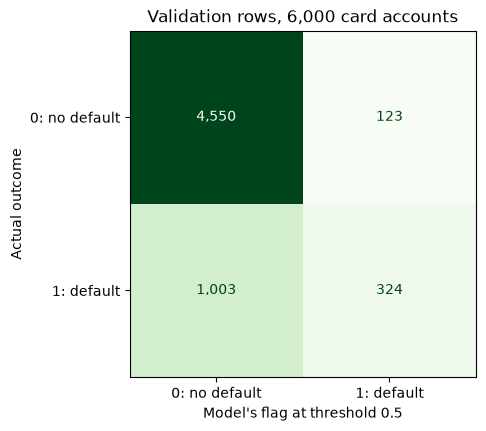

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(y_valid, flag_valid, display_labels=["0: no default", "1: default"],
                                        cmap="Greens", values_format=",", colorbar=False, ax=ax)
# the course's words on the axes: what happened down the side, the model's flag across the top
ax.set_xlabel("Model's flag at threshold 0.5")
ax.set_ylabel("Actual outcome")
ax.set_title("Validation rows, 6,000 card accounts")
plt.show()

* `ConfusionMatrixDisplay` draws scikit-learn's layout, so the cells sit where the table put them. The axis titles are set by hand to the course's words. The darkest cell is the true negatives: most of the rows, and most of the accuracy.

## 7.3 Precision, Recall, and F1, for the Default Class

Three ratios read the matrix for the class the model is looking for, the defaults:

| Metric | Formula | Reads as |
| --- | --- | --- |
| Precision | TP / (TP + FP) | Of the accounts flagged, the share that defaulted |
| Recall | TP / (TP + FN) | Of the accounts that defaulted, the share flagged |
| F1 | 2TP / (2TP + FP + FN) | The harmonic mean of precision and recall: high only when both are |

Precision looks along the **flagged 1 column**; recall looks along the **actual 1 row**. Neither uses the true negatives, which is why neither can be flattered by a file full of zeros. The course computes all three for class 1 (`pos_label=1`), and when nothing is flagged it calls precision 0 rather than stopping on a division by zero (`zero_division=0`).

Q. Compute the three by hand from the four counts.

In [19]:
tn, fp, fn, tp = counts_model["tn"], counts_model["fp"], counts_model["fn"], counts_model["tp"]

precision_by_hand = tp / (tp + fp)
recall_by_hand = tp / (tp + fn)
f1_by_hand = 2 * tp / (2 * tp + fp + fn)
print(f"precision {tp} / ({tp} + {fp}) = {precision_by_hand:.4f}")
print(f"recall    {tp} / ({tp} + {fn}) = {recall_by_hand:.4f}")
print(f"F1        2 x {tp} / (2 x {tp} + {fp} + {fn}) = {f1_by_hand:.4f}")

precision 324 / (324 + 123) = 0.7248
recall    324 / (324 + 1003) = 0.2442
F1        2 x 324 / (2 x 324 + 123 + 1003) = 0.3653


* **Precision 0.7248**: of the 447 accounts flagged, 324 defaulted. When this model flags an account at 0.5, it is a default about 7 times in ten.
* **Recall 0.2442**: of the 1,327 defaults, 324 were flagged. About three defaults in four go unflagged.
* **F1 0.3653**: pulled toward the weaker of the two. A harmonic mean punishes imbalance: precision of 1 and recall of 0 give an F1 of 0, where a plain average would say 0.5.

Q. Add `classification_metrics` to `mlkit.py`: accuracy, precision, recall, and F1 for class 1, from 0/1 flags.

In [20]:
%%writefile -a mlkit.py


def classification_metrics(y_true: ArrayLike, y_flag: ArrayLike) -> dict[str, float]:
    """Accuracy, precision, recall, and F1 for class 1 (default), from 0/1 flags.

    Inputs: y_true and y_flag, as confusion_counts.
    Output: {"accuracy", "precision", "recall", "f1"}, each between 0 and 1:
    accuracy (TP + TN) / n; precision TP / (TP + FP), the share of flagged rows that are defaults; recall
    TP / (TP + FN), the share of defaults that are flagged; F1 their harmonic mean, 2TP / (2TP + FP + FN).
    Convention: pos_label=1, binary averaging, zero_division=0 (a model that flags nothing has precision 0, not
    an error), as scikit-learn's functions with those arguments.
    Excel: =TP/(TP+FP), =TP/(TP+FN) with the COUNTIFS cells.
    Raises ValueError as confusion_counts.
    """
    counts = confusion_counts(y_true, y_flag)
    tn, fp, fn, tp = counts["tn"], counts["fp"], counts["fn"], counts["tp"]
    # each ratio is 0 when its denominator is 0 (zero_division=0)
    accuracy = (tp + tn) / (tn + fp + fn + tp)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * tp / (2 * tp + fp + fn) if tp + fp + fn else 0.0
    return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}

Appending to mlkit.py


* It calls `confusion_counts`, so the label check and the four counts are written once. Each ratio falls back to 0 when its denominator is 0: the `zero_division=0` convention, written out.

Q. Add the last three tests: agreement with scikit-learn and with Excel, the zero-division convention, and the refusal of labels other than 0 and 1.

In [21]:
%%writefile -a test_mlkit.py


def test_metrics_match_sklearn():
    y, flags = pay0_flags()
    metrics = mlkit.classification_metrics(y, flags)
    assert metrics["accuracy"] == pytest.approx(accuracy_score(y, flags), abs=1e-12)
    assert metrics["precision"] == pytest.approx(precision_score(y, flags, zero_division=0), abs=1e-12)
    assert metrics["recall"] == pytest.approx(recall_score(y, flags, zero_division=0), abs=1e-12)
    assert metrics["f1"] == pytest.approx(f1_score(y, flags, zero_division=0), abs=1e-12)
    for name in ("accuracy", "precision", "recall", "f1"):
        assert metrics[name] == pytest.approx(excel(f"d07_confusion_pay0_at_0.5:{name}"), abs=1e-12)


def test_metrics_zero_division():
    # a model that flags nothing: precision, recall, and F1 are 0 by convention, not an error
    metrics = mlkit.classification_metrics([0, 1, 1, 0], [0, 0, 0, 0])
    assert metrics == {"accuracy": 0.5, "precision": 0.0, "recall": 0.0, "f1": 0.0}


def test_rejects_labels_other_than_0_1():
    with pytest.raises(ValueError, match="other than 0 and 1"):
        mlkit.confusion_counts([0, 1, 2], [0, 1, 1])
    with pytest.raises(ValueError):
        mlkit.classification_metrics([0, 1], [True, 0.5])

Appending to test_mlkit.py


* `test_metrics_zero_division` is a model that flags nothing on four rows: accuracy 0.5, and precision, recall, and F1 all 0, by convention rather than by error.

Q. Reload and run all the tests.

In [22]:
importlib.reload(mlkit)
print(f"classification_metrics in mlkit: {hasattr(mlkit, 'classification_metrics')}")

classification_metrics in mlkit: True


In [23]:
# run the tests in the work folder with the kernel's own Python, in a fresh process
result = subprocess.run([sys.executable, "-m", "pytest", "-q", "-p", "no:cacheprovider", "test_mlkit.py"],
                        cwd=work, capture_output=True, text=True)
print(result.stdout + result.stderr)

...............................                                          [100%]
31 passed in 2.46s



* `31 passed`: the module ends the day with two new functions and five new tests.

Q. Put the model at 0.5 and the all-zero model side by side, on all four metrics.

In [24]:
side_by_side = pd.DataFrame({
    "model at 0.5": mlkit.classification_metrics(y_valid, flag_valid),
    "all-zero model": mlkit.classification_metrics(y_valid, flag_zero),
}).T
side_by_side.round(4)

,accuracy,precision,recall,f1
model at 0.5,0.8123,0.7248,0.2442,0.3653
all-zero model,0.7788,0.0000,0.0000,0.0000


* On accuracy the two are 3.35 points apart. On recall they are 0.2442 against 0, and on F1 0.3653 against 0. Precision, recall, and F1 show what accuracy hid: the all-zero model catches nothing.

Q. Do the module's numbers equal scikit-learn's functions with the course's arguments?

In [25]:
from sklearn.metrics import f1_score, precision_score, recall_score

metrics_model = mlkit.classification_metrics(y_valid, flag_valid)
library = {"accuracy": accuracy_score(y_valid, flag_valid),
           "precision": precision_score(y_valid, flag_valid, pos_label=1, zero_division=0),
           "recall": recall_score(y_valid, flag_valid, pos_label=1, zero_division=0),
           "f1": f1_score(y_valid, flag_valid, pos_label=1, zero_division=0)}
for name in library:
    print(f"{name:9} equal to scikit-learn within 1e-12: {abs(metrics_model[name] - library[name]) < 1e-12}")

accuracy  equal to scikit-learn within 1e-12: True
precision equal to scikit-learn within 1e-12: True
recall    equal to scikit-learn within 1e-12: True
f1        equal to scikit-learn within 1e-12: True


* Equal. `pos_label=1` is scikit-learn's default for 0/1 labels; it is written out here because the AI check at the end of the day turns on it.

## 7.4 Threshold 0.5 and What It Catches

Q. At 0.5, how many accounts are flagged, and how many of the defaults are among them?

In [26]:
flagged = int(flag_valid.sum())
print(f"flagged at 0.5: {flagged:,} of {len(flag_valid):,} accounts ({flagged / len(flag_valid):.2%})")
print(f"defaults flagged: {tp:,} of {tp + fn:,} (recall {tp / (tp + fn):.4f})")
print(f"flagged but no default: {fp:,} of {flagged:,} flagged (1 - precision = {fp / flagged:.4f})")

flagged at 0.5: 447 of 6,000 accounts (7.45%)
defaults flagged: 324 of 1,327 (recall 0.2442)
flagged but no default: 123 of 447 flagged (1 - precision = 0.2752)


* At 0.5 the model flags 447 accounts, 7.45 percent of the rows, in a file where 22.12 percent defaulted. It flags few, and the few are mostly defaults; most defaults are not among them.
* 0.5 is not a special number for this file. It is where a probability says "more likely than not", and it is the default of scikit-learn's own method: `model.predict` flags an account when its probability is **above** 0.5. The course flags at **at least** the threshold (`proba >= t`), as day 8's ROC curve counts. The two can differ only for a probability of exactly 0.5.

Q. Do `model.predict` and the course's flag agree on these rows?

In [27]:
# predict flags proba > 0.5; the course flags proba >= 0.5
same = (model.predict(X_valid) == flag_valid).all()
exactly_half = int((proba_valid == 0.5).sum())
print(f"predict and proba >= 0.5 give the same flags: {same}; probabilities exactly 0.5: {exactly_half}")

predict and proba >= 0.5 give the same flags: True; probabilities exactly 0.5: 0


* The same flags here, because no probability is exactly 0.5. The course still writes the threshold out, so the rule is visible and can be changed.

Q. Where do the defaults' probabilities sit, against the threshold?

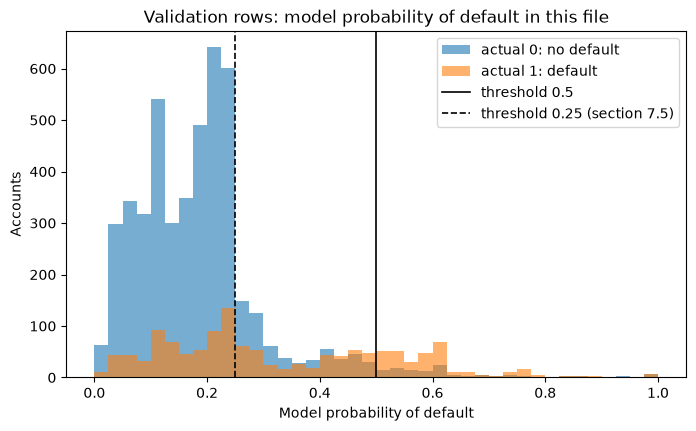

In [28]:
fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.linspace(0, 1, 41)
ax.hist(proba_valid[y_valid.to_numpy() == 0], bins=bins, alpha=0.6, label="actual 0: no default")
ax.hist(proba_valid[y_valid.to_numpy() == 1], bins=bins, alpha=0.6, label="actual 1: default")
ax.axvline(0.5, color="black", linewidth=1.2, label="threshold 0.5")
ax.axvline(0.25, color="black", linewidth=1.2, linestyle="--", label="threshold 0.25 (section 7.5)")
ax.set_title("Validation rows: model probability of default in this file")
ax.set_xlabel("Model probability of default")
ax.set_ylabel("Accounts")
ax.legend()
plt.show()

* Everything right of the solid line is flagged at 0.5. Most of the orange bars, the defaults, sit left of it, among the many accounts that did not default: those are the 1,003 false negatives. Moving the line left flags more defaults, and more of the blue bars with them. That trade is the next section.

## 7.5 What Each Error Costs, Stated as an Illustration

The two errors are different events:

| Error | What it is in this file | What it means for a reviewer of the list |
| --- | --- | --- |
| False positive | An account that did not default, flagged | Attention spent on an account that paid |
| False negative | A default, not flagged | A default the flag did not point to |

How much each one matters is not in the data. It depends on what the list is for, and this course attaches no money to either error and no rule to any count. The rest of this section is arithmetic on counts.

Q. Lower the threshold to 0.25. How do the four counts and the metrics change?

In [29]:
rows = []
for threshold in [0.5, 0.25]:
    # flagged at threshold t: probability at least t
    flags = (proba_valid >= threshold).astype(int)
    rows.append({"threshold": threshold, **mlkit.confusion_counts(y_valid, flags), **mlkit.classification_metrics(y_valid, flags)})
by_threshold = pd.DataFrame(rows).set_index("threshold")
by_threshold.round(4)

,tn,fp,fn,tp,accuracy,precision,recall,f1
threshold,,,,,,,,
0.50,4550,123,1003,324,0.8123,0.7248,0.2442,0.3653
0.25,3946,727,617,710,0.7760,0.4941,0.5350,0.5137


* At 0.25 the model flags 1,437 accounts instead of 447. TP rises from 324 to 710 and FP from 123 to 727: recall goes from 0.2442 to 0.5350, precision from 0.7248 to 0.4941.
* Accuracy falls, from 0.8123 to 0.7760, now below the all-zero model's 0.7788, while the model catches 386 more defaults. Accuracy and recall can move in opposite directions.

Q. What does each extra default caught cost, in false flags?

In [30]:
extra_tp = by_threshold.loc[0.25, "tp"] - by_threshold.loc[0.5, "tp"]
extra_fp = by_threshold.loc[0.25, "fp"] - by_threshold.loc[0.5, "fp"]
print(f"from 0.5 to 0.25: {extra_tp:,} more defaults flagged and {extra_fp:,} more accounts flagged that did not default")
print(f"false flags per extra default caught: {extra_fp / extra_tp:.2f}")

from 0.5 to 0.25: 386 more defaults flagged and 604 more accounts flagged that did not default
false flags per extra default caught: 1.56


* Lowering the threshold from 0.5 to 0.25 catches 386 more defaults and adds 604 false positives: 1.56 false flags for each extra default. That ratio is a fact about this model on these rows.

Q. Suppose, only to show the arithmetic, that a missed default is counted as w false flags. Which threshold has the smaller total for w = 1, 2, and 5?

In [31]:
# total = w x FN + FP, an illustration of weighing two kinds of error; w is a choice, not a fact in the file
for w in [1, 2, 5]:
    totals = {t: w * by_threshold.loc[t, "fn"] + by_threshold.loc[t, "fp"] for t in [0.5, 0.25]}
    smaller = min(totals, key=totals.get)
    print(f"w = {w}: total at 0.5 = {totals[0.5]:,}, at 0.25 = {totals[0.25]:,}; smaller at {smaller}")

w = 1: total at 0.5 = 1,126, at 0.25 = 1,344; smaller at 0.5
w = 2: total at 0.5 = 2,129, at 0.25 = 1,961; smaller at 0.25
w = 5: total at 0.5 = 5,138, at 0.25 = 3,812; smaller at 0.25


* With w = 1 the smaller total is at 0.5 (1,126 against 1,344); with w = 2 it is at 0.25 (1,961 against 2,129), and more so with w = 5. The switch falls at w = 1.56, the ratio of the last cell.
* So which threshold is "better" is not a property of the model or the file: it follows from a weight someone chooses. The file cannot supply that weight, and none of these weights is a rule a lender uses. Day 8 makes the choice explicit in another way: it picks the highest threshold whose recall on the validation rows reaches a target the desk states, for example 70 percent, and says so as an illustration of the trade-off.

## 7.6 `classification_report`, Read Line by Line

scikit-learn prints precision, recall, and F1 for every class at once, with two kinds of average.

Q. Print the report for the model at 0.5, with 4 decimals.

In [32]:
from sklearn.metrics import classification_report

print(classification_report(y_valid, flag_valid, digits=4))

              precision    recall  f1-score   support

           0     0.8194    0.9737    0.8899      4673
           1     0.7248    0.2442    0.3653      1327

    accuracy                         0.8123      6000
   macro avg     0.7721    0.6089    0.6276      6000
weighted avg     0.7985    0.8123    0.7739      6000



Line by line:

* **Row `1`**: precision 0.7248, recall 0.2442, F1 0.3653. The defaults: the numbers of section 7.3. `support` is the number of rows actually in the class, 1,327.
* **Row `0`**: the same three numbers with **0 treated as the positive class**. Its recall, 0.9737, is TN / (TN + FP): the share of accounts that did not default and were left unflagged. It is a true statement about the other class, and it is not the recall of the defaults.
* **`accuracy`**: 0.8123, one number for all rows, so it has no precision or recall beside it.
* **`macro avg`**: the plain average of the two class rows. Each class counts the same, whatever its size.
* **`weighted avg`**: the average weighted by `support`. With 77.88 percent of the rows in class 0, it leans toward class 0's numbers, which is the accuracy problem again in another form.

The course reads row `1`. A summary that quotes "recall 0.9737" for this model has read the wrong row: that is today's AI check.

## Excel Side by Side

The validation rows are pasted onto a sheet named `valid`: the actual outcome (0 or 1) in column A and the model's probability in column B, rows 2 to 6001, with the threshold 0.5 in F1. The split and the model come from Python; every formula below was typed into Excel by script on those rows (Excel 16.0 build 20430, 2026-10-04).

| Job | Python | Excel | Excel returned |
| --- | --- | --- | --- |
| True negatives | `confusion_counts(...)["tn"]` | `=COUNTIFS($A$2:$A$6001,0,$B$2:$B$6001,"<"&F$1)` in F2 | 4,550 |
| False positives | `["fp"]` | `=COUNTIFS($A$2:$A$6001,0,$B$2:$B$6001,">="&F$1)` in F3 | 123 |
| False negatives | `["fn"]` | `=COUNTIFS($A$2:$A$6001,1,$B$2:$B$6001,"<"&F$1)` in F4 | 1,003 |
| True positives | `["tp"]` | `=COUNTIFS($A$2:$A$6001,1,$B$2:$B$6001,">="&F$1)` in F5 | 324 |
| Precision | `classification_metrics(...)["precision"]` | `=F5/(F5+F3)` | 0.7248 |
| Recall | `["recall"]` | `=F5/(F5+F4)` | 0.2442 |
| Accuracy | `["accuracy"]` | `=(F5+F2)/COUNT($A$2:$A$6001)` | 0.8123 |
| F1 | `["f1"]` | `=2*F5/(2*F5+F3+F4)` | 0.3653 |
| All-zero accuracy | `accuracy_score(y_valid, flag_zero)` | `=COUNTIF($A$2:$A$6001,0)/COUNT($A$2:$A$6001)` | 0.7788 |

**`COUNTIFS` with two conditions is one cell of the matrix.** `=COUNTIFS($A$2:$A$6001,1,$B$2:$B$6001,">="&F$1)` counts the rows where column A is 1 **and** column B is at least the threshold. `">="&F$1` joins the text `>=` to the value in F1, so the condition reads `>=0.5`; the false negatives use `"<"&F$1`. Because the threshold sits in one cell, typing 0.25 there recounts all four cells and the four ratios. On the same sheet, 0.25 in G1 gave TP 710 and FP 727, recall 0.5350 and precision 0.4941, section 7.5's row.

**A flag column works too.** `=IF(B2>=$F$1,1,0)` in C2, filled down (the next row reads `=IF(B3>=$F$1,1,0)`), writes the flag itself; then `=COUNTIFS($A$2:$A$6001,1,$C$2:$C$6001,1)` counts the true positives from the flags, 324, the same number. That is `mlkit.confusion_counts(y_true, y_flag)` written as formulas.

The reference file holds the same `COUNTIFS` on all 30,000 accounts for the `PAY_0` model, which today's tests read.

In [33]:
# Excel's numbers on the validation rows at threshold 0.5, from the day's Excel check, beside Python's
excel_counts = {"tn": 4550, "fp": 123, "fn": 1003, "tp": 324}
excel_ratios = {"precision": 0.7248322147651006, "recall": 0.24415975885455915, "accuracy": 0.8123333333333334, "f1": 0.3652762119503946}

print(f"COUNTIFS counts equal confusion_counts exactly: {excel_counts == counts_model}")
for name, excel_value in excel_ratios.items():
    print(f"{name:9} Excel {excel_value:.4f}   Python {metrics_model[name]:.4f}   within 1e-12: {abs(excel_value - metrics_model[name]) < 1e-12}")

COUNTIFS counts equal confusion_counts exactly: True
precision Excel 0.7248   Python 0.7248   within 1e-12: True
recall    Excel 0.2442   Python 0.2442   within 1e-12: True
accuracy  Excel 0.8123   Python 0.8123   within 1e-12: True
f1        Excel 0.3653   Python 0.3653   within 1e-12: True


* The four counts are equal, whole number for whole number, and the four ratios agree to 1e-12.

## Save the Day with Git

Today's Git step reads a change of threshold in the experiment log. The model stays the same; only the threshold moves, and `git diff --word-diff` shows exactly which numbers changed with it.

Q. Make the work folder a repository.

In [34]:
# stop here, with the steps to install it, if Git is not on this machine
if shutil.which("git") is None:
    raise RuntimeError("Git is not installed. Install Git for Windows from https://git-scm.com/downloads "
                       "(or run  winget install --id Git.Git  where your firm allows it), restart VS Code, "
                       "and run this cell again. Colab has Git already.")

# -C "{work}" points every Git command at the work folder, whatever folder the notebook is in
!git -C "{work}" --version
# make the work folder a repository
!git -C "{work}" init -q -b main
# settings for this repository only: a course name, a reserved example email, line endings left as they are,
# and no commit signing, so a signing setup on your machine does not ask for a key here
!git -C "{work}" config user.name "Course Student"
!git -C "{work}" config user.email "student@example.com"
!git -C "{work}" config core.autocrlf false
!git -C "{work}" config commit.gpgsign false

git version 2.50.1.windows.1


Q. Is Git working in the work folder, and only there?

In [35]:
# the guard: Git must report the work folder as the top of this repository, or the notebook stops
top = subprocess.run(["git", "-C", str(work), "rev-parse", "--show-toplevel"],
                     capture_output=True, text=True, check=True).stdout.strip()
assert os.path.samefile(top, work), "Git is not working in the work folder. Stop, and run the setup cell again."
print(f"Git is working in {work.name} and nowhere else")

Git is working in pfi_course4_07_cyuxmjei and nowhere else


Q. Ignore what is never tracked, then commit the module and its tests.

In [36]:
%%writefile .gitignore
__pycache__/
.pytest_cache/
*.xlsx

Writing .gitignore


In [37]:
!git -C "{work}" add .gitignore mlkit.py test_mlkit.py
!git -C "{work}" commit -q -m "mlkit: confusion_counts and classification_metrics, with five tests"
!git -C "{work}" log --oneline

c2055b0 mlkit: confusion_counts and classification_metrics, with five tests


Q. Write the model's validation metrics at threshold 0.5 to `results.csv`, and commit it.

Week 2's log has its own columns, the same on every day of the week: the model, the rows it was scored on, ROC AUC and average precision, the threshold, and the four metrics. A classifier is described by these, not by errors in bp. ROC AUC and average precision are day 8's, so their cells stay empty today.

In [38]:
def log_results(threshold):
    """Write results.csv: one row for the 19-column logistic model, flagged at the threshold, on validation rows."""
    flags = (proba_valid >= threshold).astype(int)
    metrics = mlkit.classification_metrics(y_valid, flags)
    # week 2's columns; roc_auc and average_precision come on day 8, so None leaves their cells empty
    row = {"model": "logistic_19_columns_scaled", "rows": "validation", "roc_auc": None, "average_precision": None,
           "threshold": threshold}
    row.update(metrics)
    # 4 decimals, so a diff shows a real change and not the last digits of a float
    pd.DataFrame([row]).to_csv("results.csv", index=False, float_format="%.4f", lineterminator="\n")


log_results(0.5)
print((work / "results.csv").read_text(encoding="utf-8"))

model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
logistic_19_columns_scaled,validation,,,0.5000,0.8123,0.7248,0.2442,0.3653



In [39]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: the 19-column logistic model at threshold 0.5, validation rows"

Q. Change the threshold to 0.25 and read the change with `git diff --word-diff`.

In [40]:
log_results(0.25)
!git -C "{work}" diff --word-diff results.csv

diff --git a/results.csv b/results.csv
index 590895d..4979305 100644
--- a/results.csv
+++ b/results.csv
@@ -1,2 +1,2 @@
model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
[-logistic_19_columns_scaled,validation,,,0.5000,0.8123,0.7248,0.2442,0.3653-]{+logistic_19_columns_scaled,validation,,,0.2500,0.7760,0.4941,0.5350,0.5137+}


* `--word-diff` marks removed text as `[-...-]` and added text as `{+...+}` instead of whole lines. A word, to Git, is text between spaces, and this CSV row has none, so the whole row is one word. Tell Git that a word is anything between commas (and not a space or a line end):

In [41]:
!git -C "{work}" diff --word-diff-regex="[^,[:space:]]+" results.csv

diff --git a/results.csv b/results.csv
index 590895d..4979305 100644
--- a/results.csv
+++ b/results.csv
@@ -1,2 +1,2 @@
model,rows,roc_auc,average_precision,threshold,accuracy,precision,recall,f1
logistic_19_columns_scaled,validation,,,[-0.5000,0.8123,0.7248,0.2442,0.3653-]{+0.2500,0.7760,0.4941,0.5350,0.5137+}


* Now the fields that did not change stand outside the brackets: the model, the rows, and the two empty cells. The threshold and the four metrics sit side by side in the row and all changed, so Git marks them as one run: the old five values, then the new five. Accuracy went down and recall went up, in one line of the log.

In [42]:
!git -C "{work}" add results.csv
!git -C "{work}" commit -q -m "Experiment log: the same model at threshold 0.25"
!git -C "{work}" log --oneline

d46bee3 Experiment log: the same model at threshold 0.25
b6f3439 Experiment log: the 19-column logistic model at threshold 0.5, validation rows
c2055b0 mlkit: confusion_counts and classification_metrics, with five tests


* Three commits: the code, then the log at 0.5, then the log at 0.25. `git log -p results.csv` would show the whole history of thresholds tried.

## Bring It Home

Add today's two functions and five tests to your own `my_bondmath` folder. The card file is already there from day 6, so no data file is copied today.

**Step 1.** Open the folder and the two files.

```powershell
Set-Location "$HOME\projects\my_bondmath"
code mlkit.py
code test_mlkit.py
```

**Step 2.** Paste the code of the two `%%writefile -a mlkit.py` cells (sections 7.2 and 7.3), without their first lines, at the end of `mlkit.py`, one after the other; do the same for the two `%%writefile -a test_mlkit.py` cells. Save both.

**Step 3.** Run the tests.

```powershell
python -m pytest -q test_mlkit.py
```

The last line says `31 passed`.

**Step 4.** Read the change, then commit the code only.

```powershell
git diff --stat
git add mlkit.py test_mlkit.py
git commit -m "mlkit: confusion_counts and classification_metrics, with five tests"
git log --oneline -3
```

**In Colab**, download `mlkit.py` and `test_mlkit.py` from the work folder under `/tmp` in the file browser.

## You Can Now

* Score the all-zero model and say why its accuracy hides the rare class.
* Lay out a confusion matrix with labels and read TN, FP, FN, and TP cell by cell, with `confusion_counts`.
* Compute precision, recall, and F1 for the default class with `classification_metrics`, and say what each one reads along.
* Say what threshold 0.5 catches, how `predict` differs from `proba >= t`, and what lowering the threshold trades, in counts.
* State the two kinds of error in neutral terms, and say why weighing them is a choice the file cannot make.
* Read `classification_report` row by row, and find the row that belongs to the defaults.
* Count the four cells in Excel with `COUNTIFS` and match them exactly.
* Read a change of threshold in the experiment log with `git diff --word-diff`.

Tomorrow, day 8, looks at every threshold at once: the ROC curve, the precision-recall curve, and choosing a threshold on the validation rows for a recall the desk states.

## Exercises

The exercises use the same 30,000 card accounts (real data, Taiwan, 2005, cited at the top) and the same split; every number is on the validation rows, and none is a statement about any person or a rule for lending. Replace each `...` with your own code, then run the check cell. Worked answers are in the solutions notebook in this folder.

Q. Run the next cell first. It loads the accounts, makes the week 2 split, fits day 6's model on the training rows, flags the validation rows at 0.5, and defines `check`, a small function that marks your answers.

In [43]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# the card accounts and the 19 non-person columns
card = pd.read_csv("credit_card_default.csv")
TARGET = "default payment next month"
FEATURES = (["LIMIT_BAL", "PAY_0"] + [f"PAY_{i}" for i in range(2, 7)]
            + [f"BILL_AMT{i}" for i in range(1, 7)] + [f"PAY_AMT{i}" for i in range(1, 7)])

# the week 2 split: 60/20/20, stratified; the test rows stay put away
X, y = card[FEATURES], card[TARGET]
X_rest, X_test, y_rest, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
X_train, X_valid, y_train, y_valid = train_test_split(X_rest, y_rest, test_size=0.25, stratify=y_rest, random_state=SEED)

# day 6's model on the training rows; the model probability of default for each validation row; flags at 0.5
model = Pipeline([("scale", StandardScaler()), ("logistic", LogisticRegression())]).fit(X_train, y_train)
proba_valid = model.predict_proba(X_valid)[:, 1]
flag_valid = (proba_valid >= 0.5).astype(int)


def check(label, answer, expected):
    """Compare an exercise answer with the expected value and print the result."""
    if answer is ...:
        print(f"{label}: not attempted yet")
        return
    if isinstance(expected, float):
        # numbers with a decimal point: within a small tolerance
        correct = abs(answer - expected) < 1e-6
    else:
        correct = answer == expected
    if correct:
        print(f"{label}: correct")
    else:
        print(f"{label}: not yet. You have {answer}.")

### Exercise 1

Q. Flag the validation rows at threshold 0.3 (probability at least 0.3) and store the four counts, as `mlkit.confusion_counts` returns them, in **ex1_counts**.

In [44]:
ex1_counts = ...

In [45]:
check("Exercise 1 the counts at 0.3", ex1_counts, {'tn': 4220, 'fp': 453, 'fn': 733, 'tp': 594})

Exercise 1 the counts at 0.3: not attempted yet


### Exercise 2

Q. Fit the same pipeline (scaler, then logistic regression) on the training rows with `PAY_0` alone. Flag the validation rows at 0.5 and store the precision and recall for the defaults in **ex2_precision** and **ex2_recall**.

In [46]:
ex2_precision = ...
ex2_recall = ...

In [47]:
check("Exercise 2 the precision", ex2_precision, 0.6830870279146142)
check("Exercise 2 the recall", ex2_recall, 0.31348907309721175)

Exercise 2 the precision: not attempted yet
Exercise 2 the recall: not attempted yet


### Exercise 3

Q. Add a function to your module. `flag_rate(y_flag)` returns the share of rows flagged, between 0 and 1. Write the docstring first. It should refuse an empty input and labels other than 0 and 1; the module already has a helper that checks exactly that. Then add `test_flag_rate_hand_value`, which checks `[0, 1, 1, 0]` gives 0.5, three zeros give 0.0, and `[0, 2]` raises `ValueError`. Run pytest, reload the module, and store `mlkit.flag_rate(flag_valid)` in **ex3_flag_rate**.

Write the function in the cell that starts with `%%writefile -a mlkit.py` and the test in the one that starts with `%%writefile -a test_mlkit.py`, and run each of those cells once.

In [48]:
%%writefile -a mlkit.py


# Exercise 3: write flag_rate(y_flag) below this line

Appending to mlkit.py


In [49]:
%%writefile -a test_mlkit.py


# Exercise 3: write test_flag_rate_hand_value() below this line

Appending to test_mlkit.py


In [50]:
# run pytest, reload the module, then call your function
ex3_flag_rate = ...

In [51]:
check("Exercise 3 flag_rate at 0.5", ex3_flag_rate, 0.0745)

Exercise 3 flag_rate at 0.5: not attempted yet


### Exercise 4: AI check

You ask an AI assistant for a function that reports accuracy, precision, and recall for the defaults, and you give it a docstring as the request. **The docstring is the prompt.** This is what you gave it:

```
Accuracy, precision, and recall of the default class from 0/1 flags.

    Inputs: y_true, the actual outcome per row (1 = default); y_flag, the model's flag per row (0 or 1).
    Recall is the share of actual defaults (class 1) that the model flags: TP / (TP + FN).
    Returns: {"accuracy", "precision", "recall"}, each between 0 and 1.
```

The function below came back. It was written for this course in the style of an AI assistant's answer. It runs without an error, returns numbers between 0 and 1, and contains one bug.

In [52]:
# written for this course in the style of an AI assistant's answer. It runs, and it contains one bug.
from sklearn.metrics import accuracy_score, precision_score, recall_score


def default_metrics(y_true, y_flag):
    """Accuracy, precision, and recall of the default class from 0/1 flags.

    Inputs: y_true, the actual outcome per row (1 = default); y_flag, the model's flag per row (0 or 1).
    Recall is the share of actual defaults (class 1) that the model flags: TP / (TP + FN).
    Returns: {"accuracy", "precision", "recall"}, each between 0 and 1.
    """
    return {
        "accuracy": accuracy_score(y_true, y_flag),
        "precision": precision_score(y_true, y_flag, zero_division=0),
        # pos_label=0: the class most accounts belong to, so the recall rests on more rows
        "recall": recall_score(y_true, y_flag, pos_label=0),
    }

Q. Before you run the next cell: will the recall it reports be higher than, equal to, or lower than section 7.3's 0.2442? The docstring describes exactly section 7.3's recall.

In [53]:
ai_metrics = default_metrics(y_valid, flag_valid)
print(f"recall from default_metrics: {ai_metrics['recall']:.4f}; section 7.3: {mlkit.classification_metrics(y_valid, flag_valid)['recall']:.4f}")

recall from default_metrics: 0.9737; section 7.3: 0.2442


Q. Test the function against its docstring before you trust it.

In [54]:
# the test, written from the docstring before the code is trusted
ai_metrics = default_metrics(y_valid, flag_valid)

# recall of class 1 is TP / (TP + FN): confusion_counts' count, written out here so the message stops in this cell
actual, flagged = np.asarray(y_valid), np.asarray(flag_valid)
tp = int(np.sum((actual == 1) & (flagged == 1)))
fn = int(np.sum((actual == 1) & (flagged == 0)))
assert abs(ai_metrics["recall"] - tp / (tp + fn)) < 1e-12, \
    f"recall is {ai_metrics['recall']:.4f}, but TP / (TP + FN) for the defaults is {tp / (tp + fn):.4f}"
print("default_metrics reports the recall of the defaults")

AssertionError: recall is 0.9737, but TP / (TP + FN) for the defaults is 0.2442

Q. Read the test's message, fix the function in the cell that defines it, and run that cell and the test again until the test passes. Then store the fixed function's recall, `default_metrics(y_valid, flag_valid)["recall"]`, in **ex4_recall**.

In [55]:
# fix the function above and run the test again, then store the answer
ex4_recall = ...

In [56]:
check("Exercise 4 the fixed function's recall", ex4_recall, 0.24415975885455915)

Exercise 4 the fixed function's recall: not attempted yet


## Tidying Up

The work folder stays where it is, so you can open it: its name was printed by the setup cell, and on Windows it is under `$env:TEMP`. Every run of the setup cell makes a new one. To delete a work folder, run these lines in a cell of the same notebook session. Git marks its own files read-only, and on Windows a plain delete stops at them with a `PermissionError`, so the handler clears that flag and tries again.

```python
import stat

def clear_read_only(function, path, error):
    """Make a read-only file writable, then retry the delete that failed on it."""
    os.chmod(path, stat.S_IWRITE)
    function(path)

os.chdir(notebook_folder)
shutil.rmtree(work, onexc=clear_read_only)
print(f"{work.name} exists: {work.exists()}")
```